In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import LabelEncoder 
from sklearn.preprocessing import StandardScaler 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score 
from sklearn.metrics import f1_score 
from sklearn.metrics import roc_auc_score 
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve 
import warnings 
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("/kaggle/input/datasets/rashadrmammadov/heart-disease-prediction/heart_disease_dataset.csv")

print(df)
print("No. of rows in given dataset is :", df.shape[0])
print("No. of coulmns in given dataset is :", df.shape[1])

     Age  Gender  Cholesterol  Blood Pressure  Heart Rate  Smoking  \
0     75  Female          228             119          66  Current   
1     48    Male          204             165          62  Current   
2     53    Male          234              91          67    Never   
3     69  Female          192              90          72  Current   
4     62  Female          172             163          93    Never   
..   ...     ...          ...             ...         ...      ...   
995   56  Female          269             111          86    Never   
996   78  Female          334             145          76    Never   
997   79    Male          151             179          81    Never   
998   60  Female          326             151          68   Former   
999   53    Male          226             116          82  Current   

    Alcohol Intake  Exercise Hours Family History Diabetes Obesity  \
0            Heavy               1             No       No     Yes   
1              NaN 

In [4]:
df1 = df.copy()

df1.loc[df1.loc[:,"Alcohol Intake"].isna(), "Alcohol Intake"] = "Never"
print(df1.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Age                      1000 non-null   int64 
 1   Gender                   1000 non-null   object
 2   Cholesterol              1000 non-null   int64 
 3   Blood Pressure           1000 non-null   int64 
 4   Heart Rate               1000 non-null   int64 
 5   Smoking                  1000 non-null   object
 6   Alcohol Intake           1000 non-null   object
 7   Exercise Hours           1000 non-null   int64 
 8   Family History           1000 non-null   object
 9   Diabetes                 1000 non-null   object
 10  Obesity                  1000 non-null   object
 11  Stress Level             1000 non-null   int64 
 12  Blood Sugar              1000 non-null   int64 
 13  Exercise Induced Angina  1000 non-null   object
 14  Chest Pain Type          1000 non-null   

In [5]:
df.isnull().sum()


Age                          0
Gender                       0
Cholesterol                  0
Blood Pressure               0
Heart Rate                   0
Smoking                      0
Alcohol Intake             340
Exercise Hours               0
Family History               0
Diabetes                     0
Obesity                      0
Stress Level                 0
Blood Sugar                  0
Exercise Induced Angina      0
Chest Pain Type              0
Heart Disease                0
dtype: int64

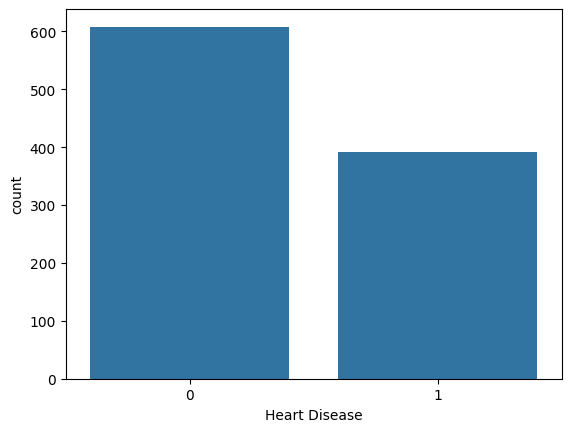

In [6]:
sns.countplot(x='Heart Disease', data=df)
plt.show()

In [7]:
import pandas as pd

df = df1

In [8]:
df.isnull().sum()

Age                        0
Gender                     0
Cholesterol                0
Blood Pressure             0
Heart Rate                 0
Smoking                    0
Alcohol Intake             0
Exercise Hours             0
Family History             0
Diabetes                   0
Obesity                    0
Stress Level               0
Blood Sugar                0
Exercise Induced Angina    0
Chest Pain Type            0
Heart Disease              0
dtype: int64

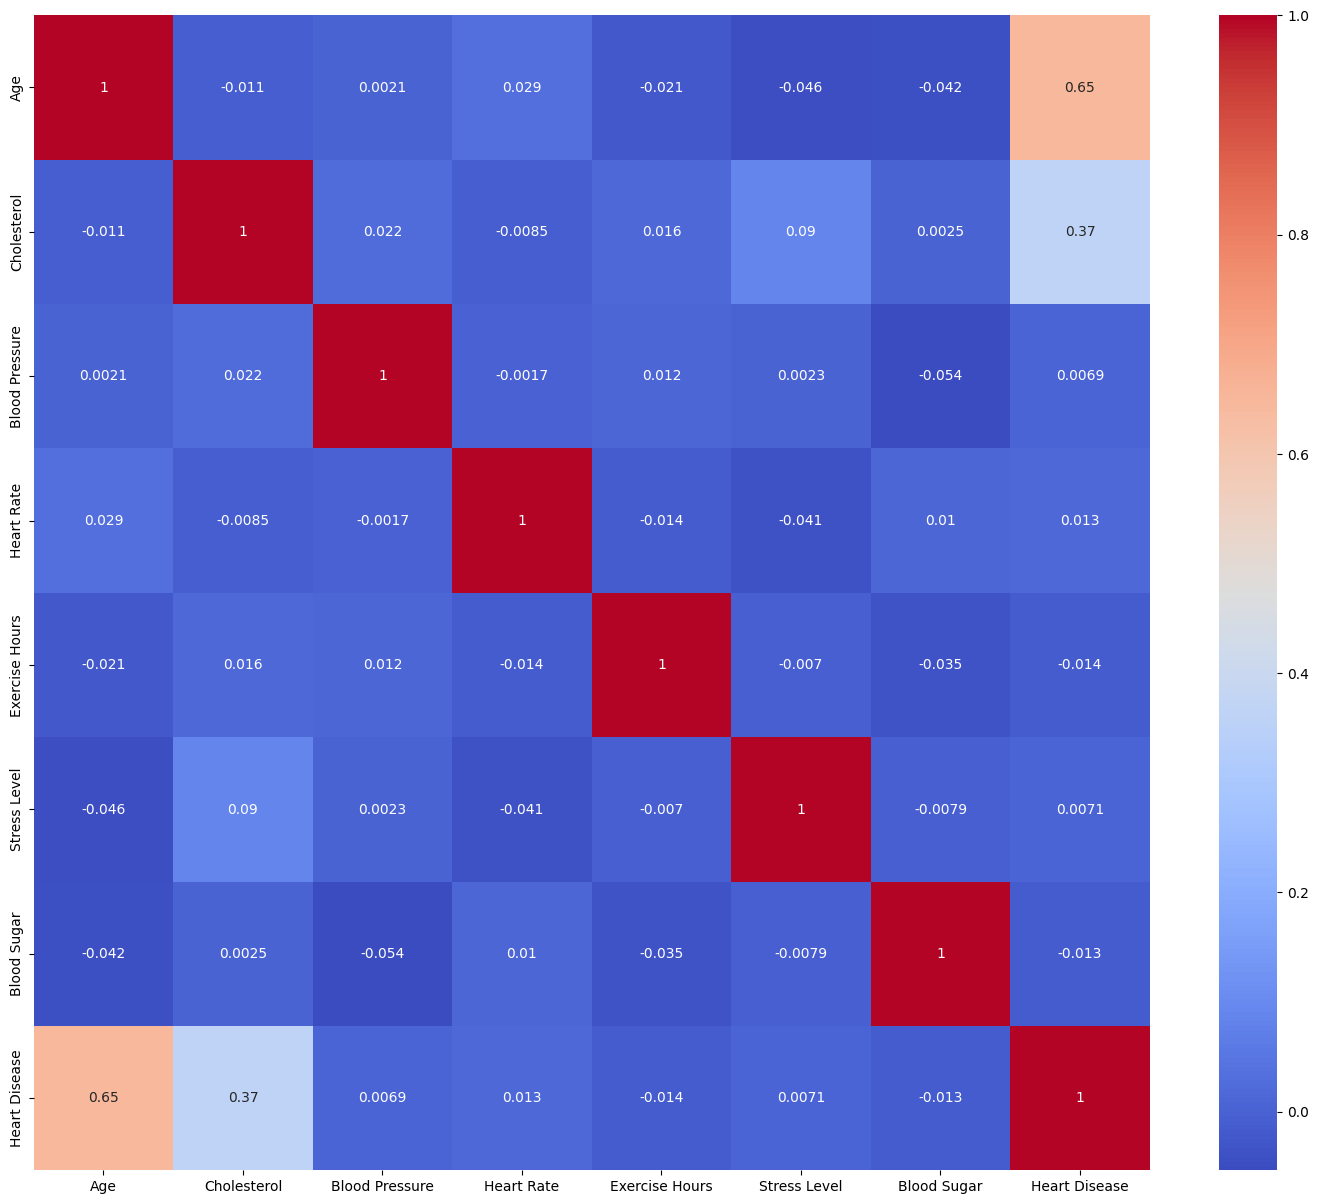

In [9]:
plt.figure(figsize=(18,15))
sns.heatmap( df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm' )
plt.show()

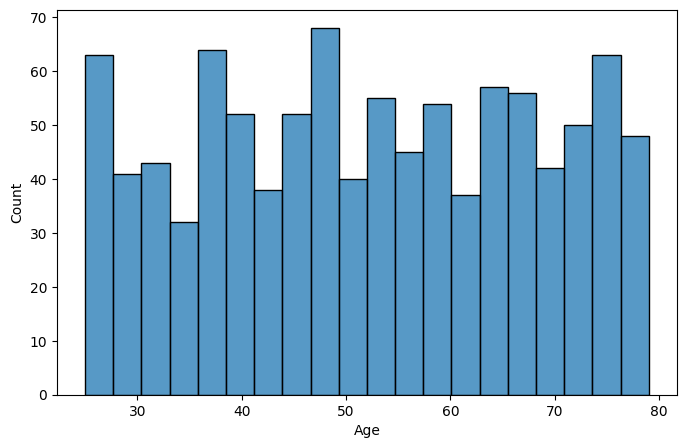

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20)
plt.show()

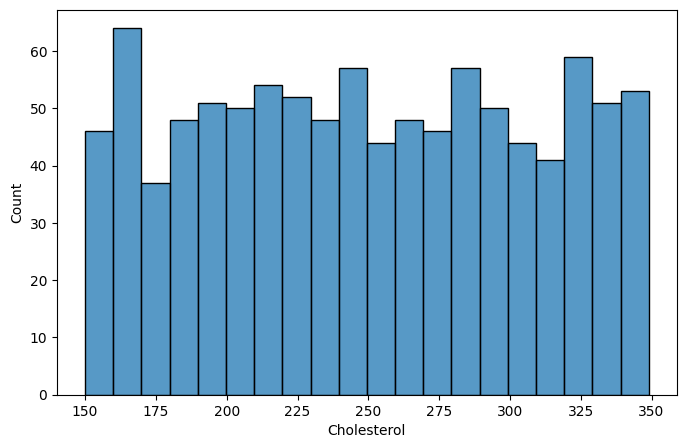

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['Cholesterol'], bins=20)
plt.show()

In [12]:
label_encoder = LabelEncoder()
for column in df.columns:
    if df[column].dtype == 'object': 
        df[column] = label_encoder.fit_transform(df[column])

In [13]:
df.head()

,Age,Gender,Cholesterol,Blood Pressure,Heart Rate,Smoking,Alcohol Intake,Exercise Hours,Family History,Diabetes,Obesity,Stress Level,Blood Sugar,Exercise Induced Angina,Chest Pain Type,Heart Disease
0,75,0,228,119,66,0,0,1,0,0,1,8,119,1,1,1
1,48,1,204,165,62,0,2,5,0,0,0,9,70,1,3,0
2,53,1,234,91,67,2,0,3,1,0,1,5,196,1,1,1
3,69,0,192,90,72,0,2,4,0,1,0,7,107,1,2,0
4,62,0,172,163,93,2,2,6,0,1,0,2,183,1,0,0


In [14]:
X = df.drop('Heart Disease', axis=1) 
y = df['Heart Disease']

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2, 
    random_state=42 )

In [17]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_prob = lr.predict_proba(X_test)[:,1]
print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall   :", recall_score(y_test, lr_pred))
print("F1 Score :", f1_score(y_test, lr_pred))
print("ROC AUC  :", roc_auc_score(y_test, lr_prob))
print(classification_report(y_test, lr_pred))

Accuracy : 0.86
Precision: 0.8375
Recall   : 0.8170731707317073
F1 Score : 0.8271604938271605
ROC AUC  : 0.9562835882596115
              precision    recall  f1-score   support

           0       0.88      0.89      0.88       118
           1       0.84      0.82      0.83        82

    accuracy                           0.86       200
   macro avg       0.86      0.85      0.85       200
weighted avg       0.86      0.86      0.86       200



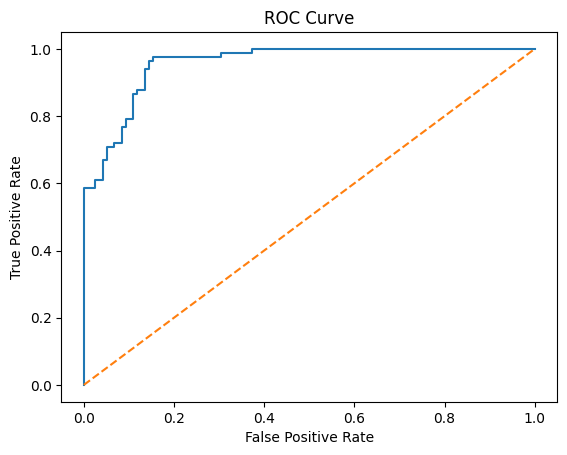

In [18]:
fpr, tpr, threshold = roc_curve(y_test, lr_prob)
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [19]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_prob = dt.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall   :", recall_score(y_test, dt_pred))
print("F1 Score :", f1_score(y_test, dt_pred))
print("ROC AUC  :", roc_auc_score(y_test, dt_prob))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC AUC  : 1.0


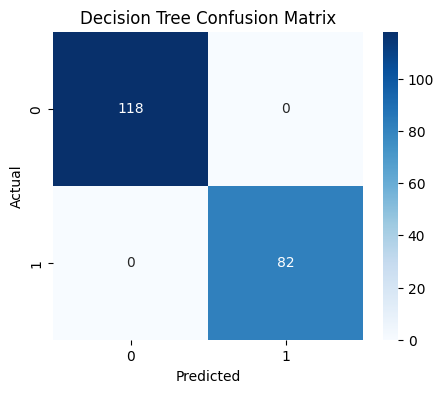

In [20]:
cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Decision Tree Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

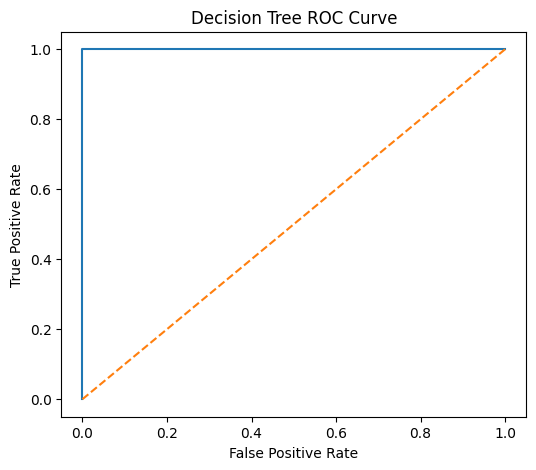

In [21]:
fpr, tpr, threshold = roc_curve(y_test, dt_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Decision Tree ROC Curve")

plt.show()

In [22]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_prob = rf.predict_proba(X_test)[:,1]
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC AUC  :", roc_auc_score(y_test, rf_prob))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC AUC  : 1.0


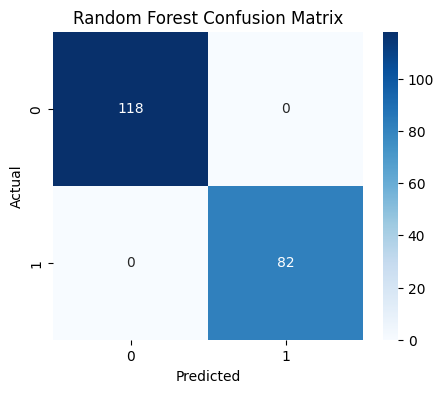

In [23]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

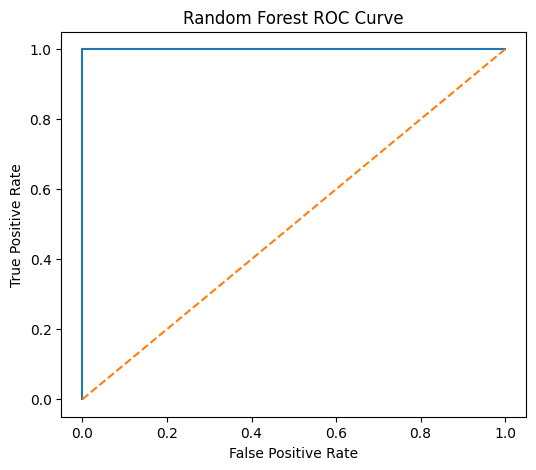

In [24]:
fpr, tpr, threshold = roc_curve(y_test, rf_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Random Forest ROC Curve")

plt.show()

In [25]:
svm = SVC(probability=True)

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

svm_prob = svm.predict_proba(X_test)[:,1]
print("Accuracy :", accuracy_score(y_test, svm_pred))
print("Precision:", precision_score(y_test, svm_pred))
print("Recall   :", recall_score(y_test, svm_pred))
print("F1 Score :", f1_score(y_test, svm_pred))
print("ROC AUC  :", roc_auc_score(y_test, svm_prob))

Accuracy : 0.915
Precision: 0.9113924050632911
Recall   : 0.8780487804878049
F1 Score : 0.8944099378881988
ROC AUC  : 0.9742662257131045


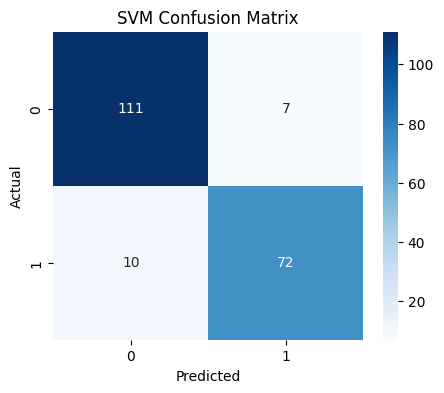

In [26]:
cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("SVM Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

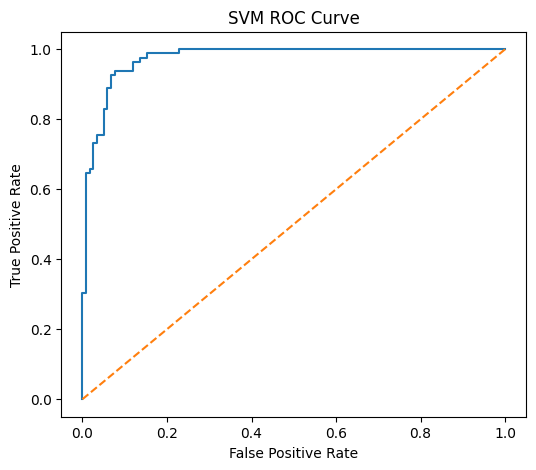

In [27]:
fpr, tpr, threshold = roc_curve(y_test, svm_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("SVM ROC Curve")

plt.show()

In [28]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

knn_prob = knn.predict_proba(X_test)[:,1]
print("Accuracy :", accuracy_score(y_test, knn_pred))
print("Precision:", precision_score(y_test, knn_pred))
print("Recall   :", recall_score(y_test, knn_pred))
print("F1 Score :", f1_score(y_test, knn_pred))
print("ROC AUC  :", roc_auc_score(y_test, knn_prob))

Accuracy : 0.8
Precision: 0.7692307692307693
Recall   : 0.7317073170731707
F1 Score : 0.75
ROC AUC  : 0.8671971889210418


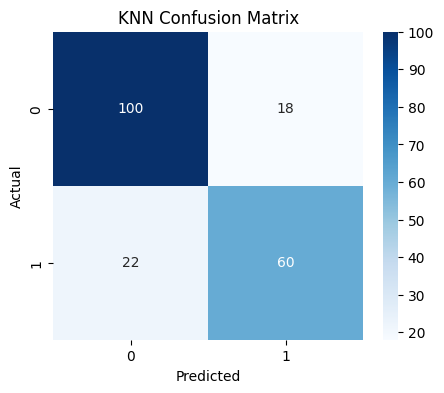

In [29]:
cm = confusion_matrix(y_test, knn_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("KNN Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

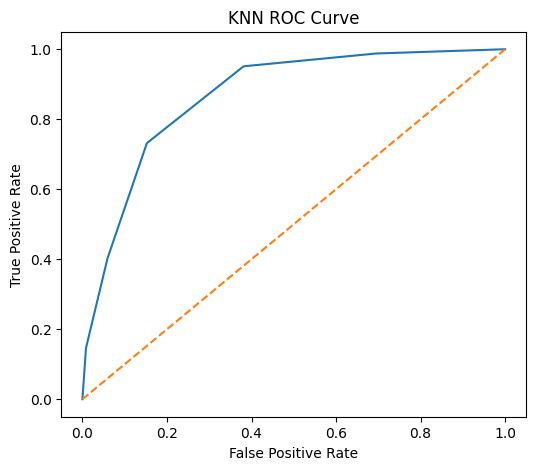

In [30]:
fpr, tpr, threshold = roc_curve(y_test, knn_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("KNN ROC Curve")

plt.show()

In [31]:
results = pd.DataFrame({ 'Model':
                        [ 'Logistic Regression', 
                         'Decision Tree',
                         'Random Forest',
                         'SVM', 
                         'KNN'
                        ],
                        'Accuracy':
                        [ accuracy_score(y_test, lr_pred),
                         accuracy_score(y_test, dt_pred),
                         accuracy_score(y_test, rf_pred),
                         accuracy_score(y_test, svm_pred),
                         accuracy_score(y_test, knn_pred)
                        ]
                        }) 
results

,Model,Accuracy
0,Logistic Regression,0.860
1,Decision Tree,1.000
2,Random Forest,1.000
3,SVM,0.915
4,KNN,0.800


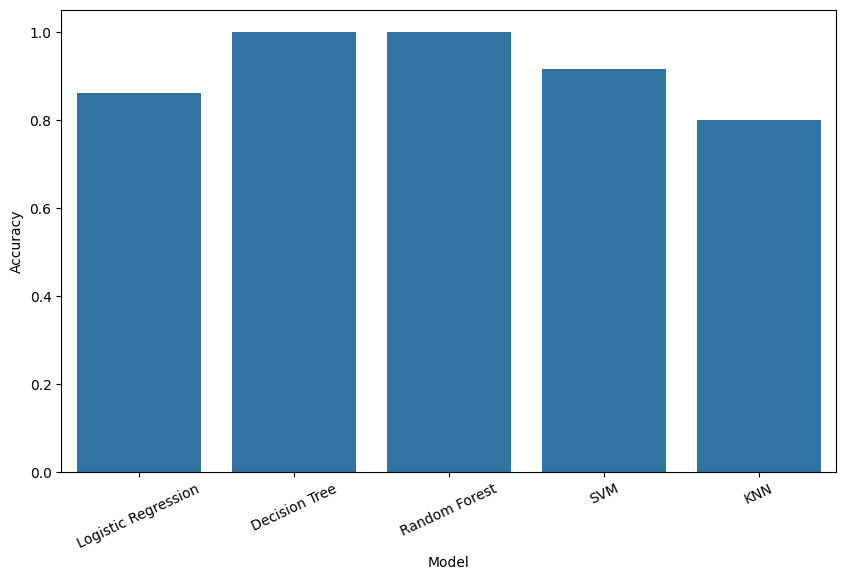

In [32]:
plt.figure(figsize=(10,6))
sns.barplot( x='Model', y='Accuracy', data=results )
plt.xticks(rotation=25)
plt.show()

In [33]:
importance = rf.feature_importances_ 
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance 
})
feature_importance = feature_importance.sort_values( by='Importance', ascending=False )
feature_importance

,Feature,Importance
0,Age,0.538316
2,Cholesterol,0.260509
12,Blood Sugar,0.035993
3,Blood Pressure,0.034182
4,Heart Rate,0.030410
7,Exercise Hours,0.021574
11,Stress Level,0.019843
5,Smoking,0.011832
14,Chest Pain Type,0.011205
6,Alcohol Intake,0.008793


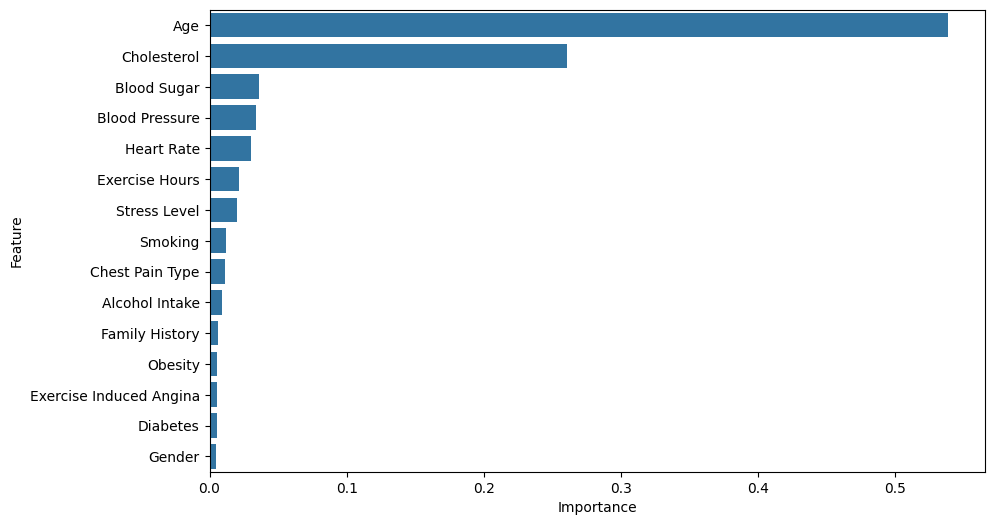

In [34]:
plt.figure(figsize=(10,6))
sns.barplot( x='Importance', y='Feature', data=feature_importance )
plt.show()

In [35]:
import joblib
joblib.dump(rf, 'heart_disease_model.pkl')

['heart_disease_model.pkl']

In [36]:
loaded_model = joblib.load('heart_disease_model.pkl')

In [37]:
sample = X_test[19].reshape(1,-1)
prediction = loaded_model.predict(sample)
print(prediction)

[0]


In [38]:

patient_data = [[
    58,
    1,
    240,
    150,
    95,
    0,
    1,
    1,
    1,
    0,
    1,
    8,
    180,
    1,
    2
]]

patient_df = pd.DataFrame(
    patient_data,
    columns=X.columns
)

print("PATIENT DETAILS")
print(patient_df)

patient_scaled = scaler.transform(patient_df.values)

prediction = loaded_model.predict(patient_scaled)

probability = loaded_model.predict_proba(patient_scaled)

print("\nPrediction Result:")

if prediction[0] == 1:
    print("Heart Disease Detected")
else:
    print("No Heart Disease Detected")

print("\nPrediction Probability:")
print(probability)



PATIENT DETAILS
   Age  Gender  Cholesterol  Blood Pressure  Heart Rate  Smoking  \
0   58       1          240             150          95        0   

   Alcohol Intake  Exercise Hours  Family History  Diabetes  Obesity  \
0               1               1               1         0        1   

   Stress Level  Blood Sugar  Exercise Induced Angina  Chest Pain Type  
0             8          180                        1                2  

Prediction Result:
Heart Disease Detected

Prediction Probability:
[[0.07 0.93]]


In [39]:

patient_data = [[
    28,
    1,
    120,
    120,
    76,
    0,
    0,
    1,
    0,
    0,
    0,
    4,
    110,
    1,
    0
]]

patient_df = pd.DataFrame(
    patient_data,
    columns=X.columns
)

print("PATIENT DETAILS")
print(patient_df)

patient_scaled = scaler.transform(patient_df.values)

prediction = loaded_model.predict(patient_scaled)

probability = loaded_model.predict_proba(patient_scaled)

print("\nPrediction Result:")

if prediction[0] == 1:
    print("Heart Disease Detected")
else:
    print("No Heart Disease Detected")

print("\nPrediction Probability:")
print(probability)



PATIENT DETAILS
   Age  Gender  Cholesterol  Blood Pressure  Heart Rate  Smoking  \
0   28       1          120             120          76        0   

   Alcohol Intake  Exercise Hours  Family History  Diabetes  Obesity  \
0               0               1               0         0        0   

   Stress Level  Blood Sugar  Exercise Induced Angina  Chest Pain Type  
0             4          110                        1                0  

Prediction Result:
No Heart Disease Detected

Prediction Probability:
[[0.97 0.03]]


In [40]:

patient_data = [[
    78,
    0,
    250,
    180,
    96,
    0,
    1,
    1,
    0,
    1,
    0,
    9,
    160,
    1,
    3
]]

patient_df = pd.DataFrame(
    patient_data,
    columns=X.columns
)

print("PATIENT DETAILS")
print(patient_df)

patient_scaled = scaler.transform(patient_df.values)

prediction = loaded_model.predict(patient_scaled)

probability = loaded_model.predict_proba(patient_scaled)

print("\nPrediction Result:")

if prediction[0] == 1:
    print("Heart Disease Detected")
else:
    print("No Heart Disease Detected")

print("\nPrediction Probability:")
print(probability)



PATIENT DETAILS
   Age  Gender  Cholesterol  Blood Pressure  Heart Rate  Smoking  \
0   78       0          250             180          96        0   

   Alcohol Intake  Exercise Hours  Family History  Diabetes  Obesity  \
0               1               1               0         1        0   

   Stress Level  Blood Sugar  Exercise Induced Angina  Chest Pain Type  
0             9          160                        1                3  

Prediction Result:
Heart Disease Detected

Prediction Probability:
[[0.12 0.88]]
